<a href="https://colab.research.google.com/github/salsilsulselsol/Data-Scientist-Supervisor-Nasional-Experiment/blob/main/03_Data_Construction_and_Documentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Data Construction, Transformation, and Documentation

**Objective:**
1. **Part A:** Execute a complete data preparation pipeline including understanding, cleaning, transformation (feature engineering & normalization), labeling, and visualization using the Titanic dataset.
2. **Part B:** Implement Simple and Multiple Linear Regression to understand variable relationships and construct predictive models.

In [1]:
# Import required libraries for the entire notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# Configure visualization aesthetic
sns.set_theme(style="whitegrid")

## PART A: Data Preparation Pipeline (Titanic Dataset)

**Dataset Context:**
The Titanic dataset contains demographics and passenger information.
Target: `survived` (0 = No, 1 = Yes).

In [2]:
# Load the Titanic dataset
df = sns.load_dataset('titanic')
print("Titanic dataset loaded successfully.")

Titanic dataset loaded successfully.


### 1. Data Understanding (Analysis and Validation)
Identify dataset dimensions, data types, missing values, and potential outliers before deciding on a cleaning strategy.

In [4]:
print("--- 1. DATASET DIMENSIONS & TYPES ---")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}\n")
print(df.dtypes)

--- 1. DATASET DIMENSIONS & TYPES ---
Total Records: 891
Total Features: 15

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [5]:
print("--- 2. MISSING VALUES IDENTIFICATION ---")
print(df.isnull().sum())

--- 2. MISSING VALUES IDENTIFICATION ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
print("--- 3. OUTLIER IDENTIFICATION (IQR METHOD) ---")
# Focus on continuous numerical features
numerical_cols = ['age', 'fare']

outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = outliers

for feature, count in outlier_summary.items():
    print(f"- {feature}: {count} potential outliers")

--- 3. OUTLIER IDENTIFICATION (IQR METHOD) ---
- age: 11 potential outliers
- fare: 116 potential outliers


### 2. Data Cleaning Strategy and Execution

**Strategy:**
1. **Missing Values:**
   - `age`: Impute with median (robust to outliers).
   - `embarked` / `embark_town`: Impute with mode.
   - `deck`: Drop the column (too many missing values, exceeds 70%).
2. **Outliers:** Clip `fare` to the upper bound to prevent extreme skewness without losing data points.

In [7]:
print("--- 1. EXECUTING MISSING VALUE IMPUTATION ---")

# Impute 'age' with median
df['age'] = df['age'].fillna(df['age'].median())

# Impute 'embarked' and 'embark_town' with mode
mode_embarked = df['embarked'].mode()[0]
mode_embark_town = df['embark_town'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)
df['embark_town'] = df['embark_town'].fillna(mode_embark_town)

# Drop 'deck' column
df.drop(columns=['deck'], inplace=True)

print("Remaining missing values:")
print(df.isnull().sum())

--- 1. EXECUTING MISSING VALUE IMPUTATION ---
Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [8]:
print("--- 2. CORRECTING OUTLIERS (CLIPPING) ---")

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip fare values
df['fare'] = df['fare'].clip(lower_bound, upper_bound)

print("Fare statistics after clipping:")
print(df['fare'].describe())

--- 2. CORRECTING OUTLIERS (CLIPPING) ---
Fare statistics after clipping:
count    891.000000
mean      24.046813
std       20.481625
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max       65.634400
Name: fare, dtype: float64


### 3. Data Transformation and Feature Engineering
Construct new meaningful features and scale continuous data to ensure machine learning model stability.

In [9]:
print("--- 1. FEATURE ENGINEERING ---")
# Create 'family_size' by combining siblings/spouses (sibsp) and parents/children (parch)
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Create categorical bins for 'age'
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teenager', 'Adult', 'Senior'])

print("New features added: 'family_size' and 'age_group'")
print(df[['sibsp', 'parch', 'family_size', 'age', 'age_group']].head())

--- 1. FEATURE ENGINEERING ---
New features added: 'family_size' and 'age_group'
   sibsp  parch  family_size   age age_group
0      1      0            2  22.0     Adult
1      1      0            2  38.0     Adult
2      0      0            1  26.0     Adult
3      1      0            2  35.0     Adult
4      0      0            1  35.0     Adult


In [10]:
print("--- 2. DATA NORMALIZATION (MIN-MAX SCALING) ---")
scaler = MinMaxScaler()
numerical_features = ['age', 'fare', 'family_size']

df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("Data after normalization (scaled to 0-1):")
print(df[numerical_features].head())

--- 2. DATA NORMALIZATION (MIN-MAX SCALING) ---
Data after normalization (scaled to 0-1):
        age      fare  family_size
0  0.271174  0.110460          0.1
1  0.472229  1.000000          0.1
2  0.321438  0.120745          0.0
3  0.434531  0.809027          0.1
4  0.434531  0.122649          0.0


### 4. Data Labeling
Map numerical target classes to descriptive text labels according to labeling SOP guidelines for reporting clarity.

In [11]:
print("--- DATA LABELING ---")
# Define mapping based on SOP
label_mapping = {
    0: 'Perished',
    1: 'Survived'
}

# Apply mapping to a new column
df['survival_status'] = df['survived'].map(label_mapping)

print("Target Class Distribution:")
print(df['survival_status'].value_counts())
print("\nDataset with updated labels:")
print(df[['survived', 'survival_status']].head())

--- DATA LABELING ---
Target Class Distribution:
survival_status
Perished    549
Survived    342
Name: count, dtype: int64

Dataset with updated labels:
   survived survival_status
0         0        Perished
1         1        Survived
2         1        Survived
3         1        Survived
4         0        Perished


### 5. Data Visualization
Visually validate the distribution of data post-cleaning and understand the relationships between engineered features and the target.

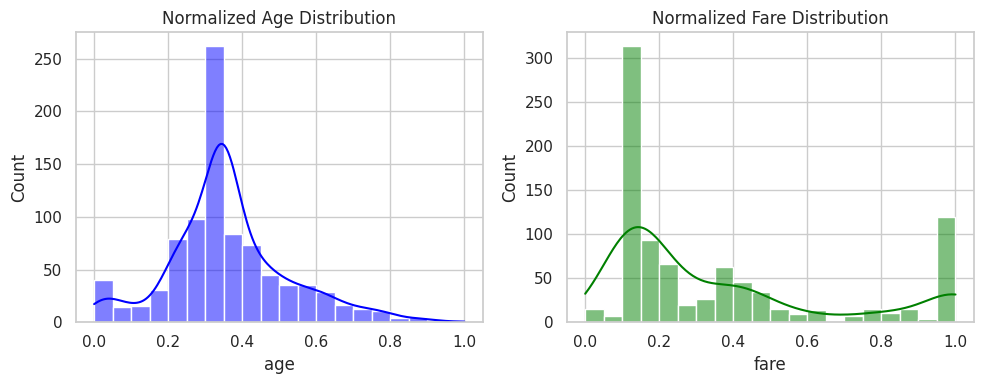

In [12]:
# 1. Distribution of Normalized Features
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, color='blue', bins=20)
plt.title('Normalized Age Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['fare'], kde=True, color='green', bins=20)
plt.title('Normalized Fare Distribution')

plt.tight_layout()
plt.show()

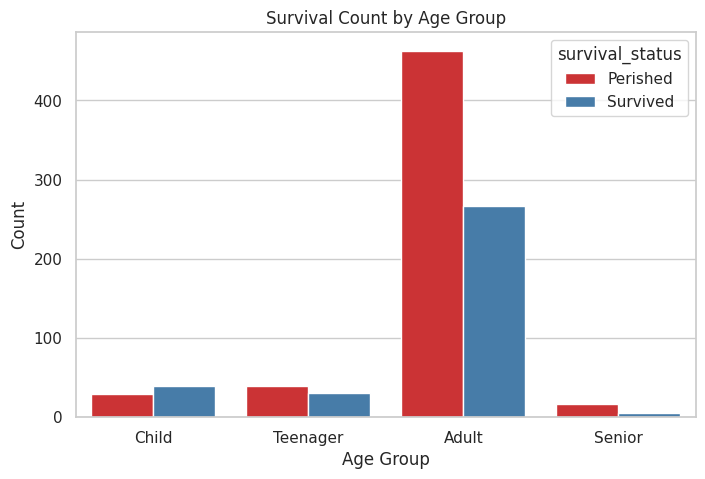

In [13]:
# 2. Survival Rate by Engineered Feature (Age Group)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='age_group', hue='survival_status', palette='Set1')
plt.title('Survival Count by Age Group')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.show()

### 6. Evaluation and Documentation Report

**Descriptive Statistics**
* **Completeness:** All missing values were successfully resolved. The `deck` attribute was dropped due to >70% sparsity, while `age` and `embarked` were imputed using median and mode.
* **Scale:** Continuous numerical features (`age`, `fare`, `family_size`) are strictly bounded within the [0, 1] range.

**Transformation Evaluation**
* **Outlier Mitigation:** The IQR clipping applied to the `fare` attribute successfully eliminated extreme positive skewness.
* **Feature Engineering:** The aggregation of `sibsp` and `parch` into `family_size` successfully reduced dimensionality.

**Labeling Evaluation**
* **Target Mapping:** The boolean target `survived` was accurately mapped to 'Perished' and 'Survived'.

**Recommendations**
1. **Categorical Encoding:** Prior to model training, strictly categorical variables must undergo One-Hot Encoding.
2. **Feature Selection:** Perform a correlation analysis to drop redundant columns.

---
## PART B: Data Construction (Regression Models)
Implement Simple Linear Regression and Multiple Linear Regression to understand relationships between variables and predict student final scores.

### 1. Simple Linear Regression
Model the linear relationship between a single independent variable (Hours Studied) and the dependent variable (Final Score) to predict future outcomes.

In [14]:
print("--- 1. DATA PREPARATION ---")
# Input data
hours_studied = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Independent variable (X)
final_scores = np.array([50, 55, 60, 65, 70])  # Dependent variable (Y)

print("Independent Variable (X): Hours Studied")
print("Dependent Variable (Y): Final Score")

--- 1. DATA PREPARATION ---
Independent Variable (X): Hours Studied
Dependent Variable (Y): Final Score


In [15]:
print("--- 2. MODEL TRAINING & PREDICTION ---")
# Create and fit the model
model_simple = LinearRegression()
model_simple.fit(hours_studied, final_scores)

# Predicting for 6 hours of study
predicted_score_simple = model_simple.predict([[6]])

# Extract model parameters
slope = model_simple.coef_[0]
intercept_simple = model_simple.intercept_

print("Linear Regression model trained successfully.")

--- 2. MODEL TRAINING & PREDICTION ---
Linear Regression model trained successfully.


--- 3. VISUALIZATION & INTERPRETATION ---


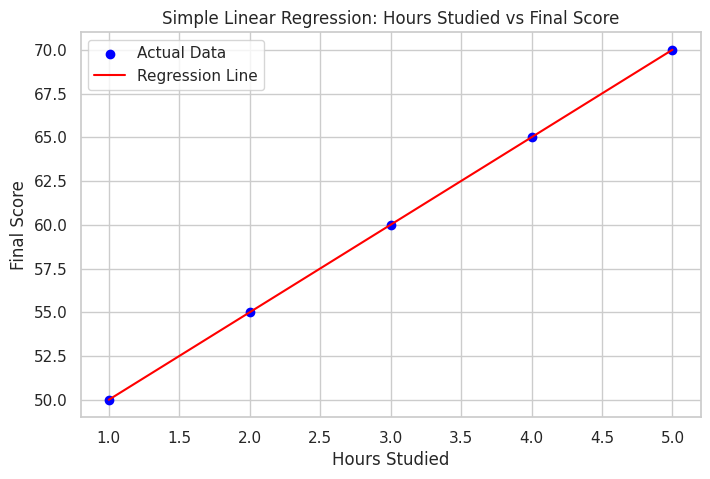

Slope (m): 4.999999999999999
Intercept (b): 45.0
Predicted score for 6 hours of study: 75.0


In [16]:
print("--- 3. VISUALIZATION & INTERPRETATION ---")
# Plotting the results
plt.figure(figsize=(8, 5))
plt.scatter(hours_studied, final_scores, color='blue', label='Actual Data')
plt.plot(hours_studied, model_simple.predict(hours_studied), color='red', label='Regression Line')
plt.title('Simple Linear Regression: Hours Studied vs Final Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.legend()
plt.grid(True)
plt.show()

# Output the interpretation metrics
print(f"Slope (m): {slope}")
print(f"Intercept (b): {intercept_simple}")
print(f"Predicted score for 6 hours of study: {predicted_score_simple[0]}")

### 2. Multiple Linear Regression
Model the linear relationship between multiple independent variables (Hours Studied, Attendance Rate, Practice Tests Taken) and the dependent variable (Final Score).

In [17]:
print("--- 1. DATA PREPARATION ---")
# Create the dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5],
    'Attendance_Rate': [85, 90, 95, 85, 90],
    'Practice_Tests_Taken': [1, 2, 3, 4, 5],
    'Final_Score': [52, 58, 64, 67, 73]
}

# Convert the dataset into a pandas DataFrame
df_reg = pd.DataFrame(data)

# Define independent variables (X) and dependent variable (y)
X = df_reg[['Hours_Studied', 'Attendance_Rate', 'Practice_Tests_Taken']]
y = df_reg['Final_Score']

print("Dataset loaded into DataFrame:")
print(df_reg)

--- 1. DATA PREPARATION ---
Dataset loaded into DataFrame:
   Hours_Studied  Attendance_Rate  Practice_Tests_Taken  Final_Score
0              1               85                     1           52
1              2               90                     2           58
2              3               95                     3           64
3              4               85                     4           67
4              5               90                     5           73


In [18]:
print("--- 2. MODEL TRAINING & PREDICTION ---")
# Create and fit the model
model_multiple = LinearRegression()
model_multiple.fit(X, y)

# Extract coefficients and intercept
coefficients = model_multiple.coef_
intercept_multiple = model_multiple.intercept_

# Predict the score for a student who studied 6 hours, attended 95% of classes, and took 6 practice tests
predicted_score_multiple = model_multiple.predict([[6, 95, 6]])

print("Multiple Linear Regression model trained successfully.")

--- 2. MODEL TRAINING & PREDICTION ---
Multiple Linear Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
print("--- 3. INTERPRETATION ---")
# Output the coefficients, intercept, and prediction
print(f"Intercept (b_0): {intercept_multiple}")
print(f"Coefficients (b_1, b_2, b_3): {coefficients}")
print(f"Predicted Final Score (6 hours, 95% attendance, 6 tests): {predicted_score_multiple[0]}")

--- 3. INTERPRETATION ---
Intercept (b_0): 29.99999999999998
Coefficients (b_1, b_2, b_3): [2.5 0.2 2.5]
Predicted Final Score (6 hours, 95% attendance, 6 tests): 79.00000000000001
